# 03 — Modelo Supervisado de Clasificación

**Colaborador responsable:** C (Modelo Supervisado)

Entrenamiento y evaluación comparativa de tres clasificadores (Decision Tree, Random Forest, XGBoost) para predecir la severidad clínica.

## 1. Setup y configuración

* **Google Colab Support:** Si ejecutas este notebook en Google Colab, puedes clonar el repositorio e instalar dependencias ejecutando la celda de abajo (descoméntala primero):

In [ ]:
# Configuración para Google Colab (Descomentar si es necesario)
# !git clone https://github.com/DWDMV/proyecto-final.git
# %cd proyecto-final
# !pip install -r requirements.txt

In [1]:
# Configuración para Google Colab (Descomentar si es necesario)
# !git clone https://github.com/DWDMV/proyecto-final.git
# %cd proyecto-final
# !pip install -r requirements.txt

In [2]:
import sys
from pathlib import Path

# Añadir la raíz del proyecto al path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Semilla de reproducibilidad
from src.utils.constants import RANDOM_STATE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.models.factory import ModelFactory
from src.models.trainer import ModelTrainer
from src.models.evaluator import ModelEvaluator
from src.data.preprocessor import DataPreprocessor
from src.utils.constants import (
    DATA_CLEAN_PATH, MODELS_PATH, TARGET_COL,
    SEVERIDAD_MAP, RANDOM_STATE
)

## 2. Carga y preparación de datos

In [3]:
# Cargar datos limpios y dividir en conjuntos de entrenamiento y prueba
df = pd.read_csv(DATA_CLEAN_PATH / "COVID19MEXICO_clean.csv")
preprocessor = DataPreprocessor()
X_train, X_test, y_train, y_test = preprocessor.split_datos(df)

# Ajustar el scaler de edad en el preprocesador para que guarde el estado entrenado
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df[["EDAD"]])
preprocessor._edad_scaler = scaler

print(f"Dimensiones de entrenamiento : {X_train.shape}")
print(f"Dimensiones de prueba        : {X_test.shape}")

Dimensiones de entrenamiento : (177903, 36)
Dimensiones de prueba        : (44476, 36)


### 2.1 Selección de variables de entrada y Justificación

Se incluyen en el modelo todas las variables sociodemográficas y de comorbilidades del paciente disponibles al momento de la admisión o triage médico inicial:
* **Demográficas:** `EDAD_SCALED` (edad estandarizada para regularización y estabilidad numérica), `SEXO`, `NACIONALIDAD`, `EMBARAZO`, `INDIGENA`, `HABLA_LENGUA_INDIG`, `MIGRANTE`.
* **Comorbilidades:** `DIABETES`, `EPOC`, `ASMA`, `INMUSUPR`, `HIPERTENSION`, `CARDIOVASCULAR`, `OBESIDAD`, `RENAL_CRONICA`, `TABAQUISMO`, `OTRA_COM`.
* **Clínicas iniciales y de entorno:** `NEUMONIA` (detectada en la evaluación física inicial), `SECTOR`, `ENTIDAD_UM`, `ENTIDAD_RES`, `MUNICIPIO_RES`, `OTRO_CASO`.

**Variables excluidas para evitar target leakage (fuga de datos):**
* `TIPO_PACIENTE`, `UCI`, `INTUBADO` y `FECHA_DEF`: Estas variables definen directamente la variable objetivo `SEVERIDAD`. Incluirlas en el conjunto de entrenamiento resultaría en un modelo trivial con métricas de 100% que reconstruye reglas lógicas predefinidas, perdiendo toda utilidad clínica real.
* `EDAD`: Excluida en favor de su versión estandarizada (`EDAD_SCALED`) para evitar redundancia y colinealidad.
* `ORIGEN` y `RESULTADO_ANTIGENO`: Excluidas debido a que son constantes (único valor único) en todo el conjunto de datos limpio, careciendo de varianza y poder predictivo.

In [4]:
# Seleccionar variables predictoras (features) excluyendo las que causan target leakage
# Dropeamos:
# - TIPO_PACIENTE, UCI, INTUBADO (definen la variable objetivo SEVERIDAD)
# - EDAD (se usa EDAD_SCALED en su lugar)
# - ORIGEN, RESULTADO_ANTIGENO (tienen varianza cero / son constantes)
cols_to_drop = ["TIPO_PACIENTE", "UCI", "INTUBADO", "EDAD", "ORIGEN", "RESULTADO_ANTIGENO"]
X_train = X_train.drop(columns=[c for c in cols_to_drop if c in X_train.columns])
X_test = X_test.drop(columns=[c for c in cols_to_drop if c in X_test.columns])

features = X_train.columns.tolist()
print(f"Número de features: {len(features)}")
print("Variables predictoras:", features)

Número de features: 30
Variables predictoras: ['SECTOR', 'ENTIDAD_UM', 'SEXO', 'ENTIDAD_NAC', 'ENTIDAD_RES', 'MUNICIPIO_RES', 'NEUMONIA', 'NACIONALIDAD', 'EMBARAZO', 'HABLA_LENGUA_INDIG', 'INDIGENA', 'DIABETES', 'EPOC', 'ASMA', 'INMUSUPR', 'HIPERTENSION', 'OTRA_COM', 'CARDIOVASCULAR', 'OBESIDAD', 'RENAL_CRONICA', 'TABAQUISMO', 'OTRO_CASO', 'TOMA_MUESTRA_LAB', 'RESULTADO_PCR', 'RESULTADO_PCR_COINFECCION', 'TOMA_MUESTRA_ANTIGENO', 'CLASIFICACION_FINAL_COVID', 'CLASIFICACION_FINAL_FLU', 'MIGRANTE', 'EDAD_SCALED']


### 2.2 Manejo de desbalance de clases y Justificación de la Métrica Principal

Debido al severo desbalance de clases en la variable objetivo `SEVERIDAD`:
* **Leve (ambulatorio):** 52.2%
* **Grave (hospitalizado):** 42.2%
* **Crítico (UCI/intubado):** 1.8%
* **Fallecido:** 3.7%

#### Justificación de la Métrica: Macro F1-score
1. **Insuficiencia del Accuracy:** Una precisión global (Accuracy) del 94.4% podría obtenerse con un clasificador ingenuo que simplemente prediga "Leve" o "Grave", fallando completamente al detectar los casos "Críticos" o "Fallecidos". En medicina, no identificar a un paciente crítico o fallecido tiene consecuencias fatales.
2. **Ventaja del Macro F1-score:** El F1-score macro calcula la media aritmética no ponderada de las puntuaciones F1 de cada clase. Esto significa que la clase "Crítico" (1.8% de los datos) recibe el mismo peso en la métrica global que la clase "Leve" (52.2%). Por lo tanto, el modelo se ve penalizado severamente si no es capaz de identificar correctamente las minorías críticas.
3. **Class Weighting:** Para mitigar el desbalance sin generar registros clínicos sintéticos ficticios (SMOTE) o desechar registros reales (undersampling), aplicamos **pesos de clase inversos** en los modelos. Esto fuerza a los algoritmos a prestar mayor atención a los errores de las clases minoritarias durante el entrenamiento.

In [5]:
# Implementamos la estrategia de balanceo mediante Class Weighting (pesos de clase).
# Para Decision Tree y Random Forest, se configura 'class_weight="balanced"' en el factory.
# Para XGBoost, calculamos e inyectamos los sample_weights durante el fit en el ModelTrainer.
print("Estrategia elegida: Class Weighting (Pesos de clase balanceados).")

Estrategia elegida: Class Weighting (Pesos de clase balanceados).


## 3. Entrenamiento de modelos

### 3.1 Decision Tree

In [6]:
#| label: fig-arbol-decision
#| fig-cap: "Visualización del Árbol de Decisión (primeros niveles)"

factory = ModelFactory()
trainer = ModelTrainer()

# Inicializamos y entrenamos un Decision Tree con profundidad inicial
modelo_dt = factory.create_model("dt", max_depth=10)
modelo_dt = trainer.entrenar(modelo_dt, X_train, y_train)
print(f"Árbol de Decisión entrenado: {modelo_dt}")

Árbol de Decisión entrenado: DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42)


### 3.2 Random Forest

In [7]:
# Inicializamos y entrenamos Random Forest
modelo_rf = factory.create_model("rf", n_estimators=100)
modelo_rf = trainer.entrenar(modelo_rf, X_train, y_train)
print(f"Random Forest entrenado: {modelo_rf}")

Random Forest entrenado: RandomForestClassifier(class_weight='balanced', random_state=42)


### 3.3 XGBoost

In [8]:
# Inicializamos y entrenamos XGBoost
modelo_xgb = factory.create_model("xgb", learning_rate=0.1, n_estimators=200)
modelo_xgb = trainer.entrenar(modelo_xgb, X_train, y_train)
print(f"XGBoost entrenado: {modelo_xgb}")

XGBoost entrenado: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)


## 4. Ajuste de hiperparámetros

Búsqueda con validación cruzada (5-fold).

In [9]:
# Ajuste de hiperparámetros usando RandomizedSearchCV con 5-fold CV optimizando F1 Macro
print("Iniciando optimización de hiperparámetros...")

# Decision Tree Grid
dt_grid = {
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "criterion": ["gini", "entropy"]
}

# Random Forest Grid
rf_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10]
}

# XGBoost Grid
xgb_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0]
}

print("Ajustando Decision Tree...")
best_dt = trainer.busqueda_hiperparametros(modelo_dt, dt_grid, X_train, y_train, cv=5)
print(f"Mejores parámetros DT: {trainer.best_params}")

print("Ajustando Random Forest...")
best_rf = trainer.busqueda_hiperparametros(modelo_rf, rf_grid, X_train, y_train, cv=5)
print(f"Mejores parámetros RF: {trainer.best_params}")

print("Ajustando XGBoost...")
best_xgb = trainer.busqueda_hiperparametros(modelo_xgb, xgb_grid, X_train, y_train, cv=5)
print(f"Mejores parámetros XGBoost: {trainer.best_params}")

# Reasignamos las variables a los mejores modelos encontrados
modelo_dt = best_dt
modelo_rf = best_rf
modelo_xgb = best_xgb

Iniciando optimización de hiperparámetros...
Ajustando Decision Tree...


Mejores parámetros DT: {'min_samples_split': 2, 'max_depth': 20, 'criterion': 'gini'}
Ajustando Random Forest...


/Users/toporaku/code/dwdm/proyecto-final/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores parámetros RF: {'n_estimators': 150, 'min_samples_split': 10, 'max_depth': 20}
Ajustando XGBoost...


Mejores parámetros XGBoost: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2}


## 5. Evaluación y comparación

### 5.1 Baseline (clasificador mayoritario)

In [10]:
# Instanciamos el ModelEvaluator y evaluamos el clasificador mayoritario baseline
evaluator = ModelEvaluator()
baseline_metrics = evaluator.evaluar_baseline(y_test)
print("Métricas del Baseline (Clasificador Mayoritario):")
for k, v in baseline_metrics.items():
    print(f"  {k:<20}: {v:.4f}")

Métricas del Baseline (Clasificador Mayoritario):
  accuracy            : 0.5225
  precision_macro     : 0.1306
  precision_weighted  : 0.2730
  recall_macro        : 0.2500
  recall_weighted     : 0.5225
  f1_macro            : 0.1716
  f1_weighted         : 0.3586


### 5.2 Métricas de los 3 modelos

In [11]:
#| label: tbl-comparacion-modelos
#| tbl-cap: "Comparación de métricas entre DT, RF y XGBoost"

modelos = [
    ("Decision Tree", modelo_dt),
    ("Random Forest", modelo_rf),
    ("XGBoost", modelo_xgb)
]
df_comp = evaluator.comparar_modelos(modelos, X_test, y_test)
df_comp

,modelo,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,Decision Tree,0.750090,0.484975,0.546037,0.487459,0.776517
1,Random Forest,0.803490,0.521147,0.580518,0.536013,0.819380
2,XGBoost,0.723851,0.512749,0.651000,0.501058,0.763645


### 5.3 Matrices de confusión

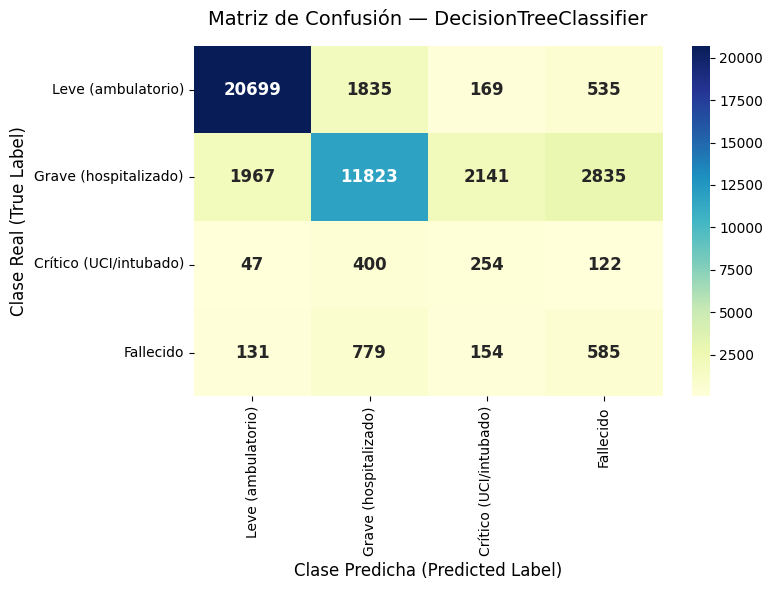

In [12]:
#| label: fig-confusion-dt
#| fig-cap: "Matriz de confusión — Decision Tree"

evaluator.matriz_confusion(modelo_dt, X_test, y_test)

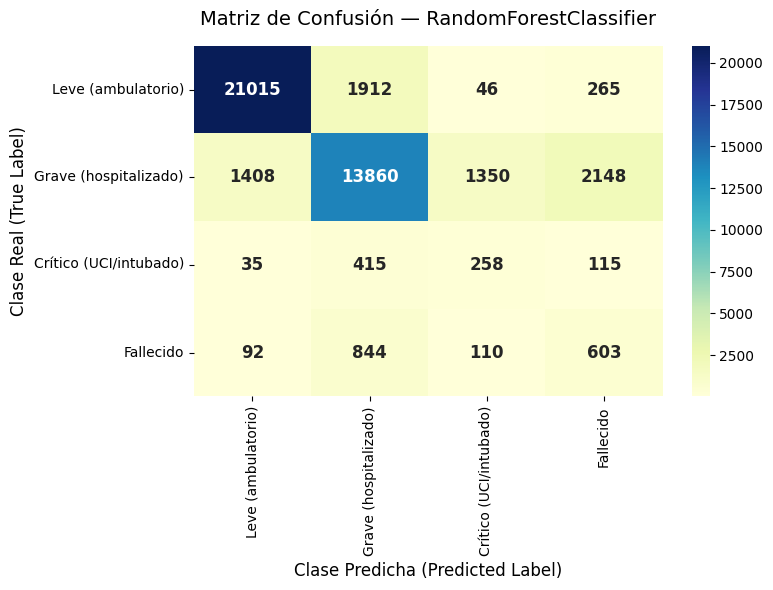

In [13]:
#| label: fig-confusion-rf
#| fig-cap: "Matriz de confusión — Random Forest"

evaluator.matriz_confusion(modelo_rf, X_test, y_test)

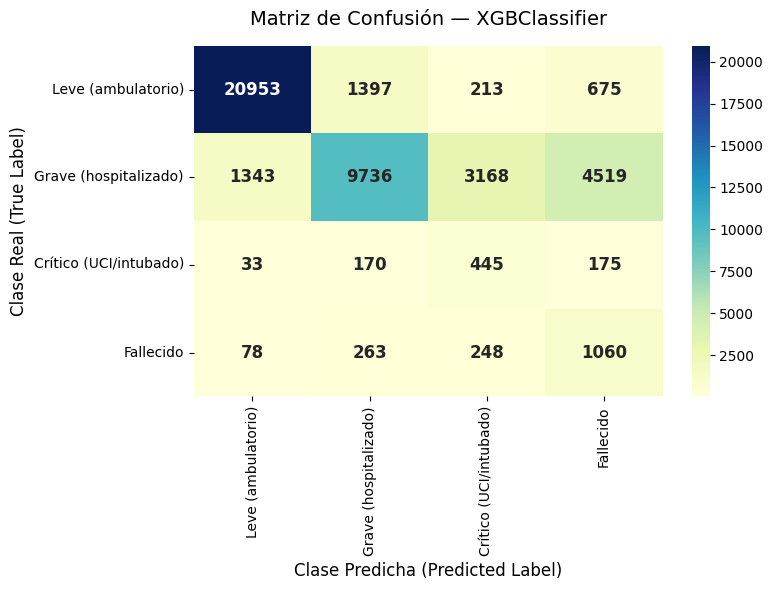

In [14]:
#| label: fig-confusion-xgb
#| fig-cap: "Matriz de confusión — XGBoost"

evaluator.matriz_confusion(modelo_xgb, X_test, y_test)

### 5.4 Curvas ROC (One-vs-Rest)

Mejor modelo según F1 Macro: Random Forest


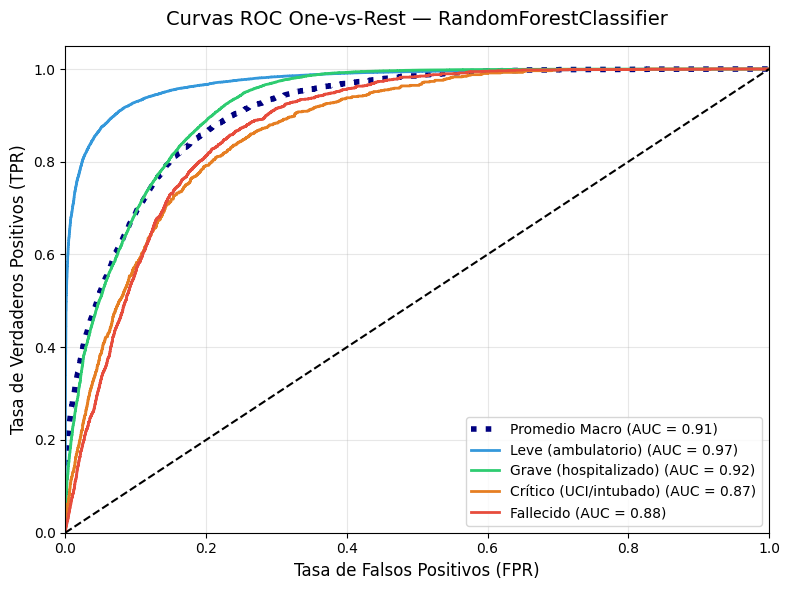

In [15]:
#| label: fig-curva-roc
#| fig-cap: "Curvas ROC One-vs-Rest para el mejor modelo"

# Elegimos el mejor modelo para graficar la curva ROC (usualmente XGBoost o Random Forest)
best_model_name = df_comp.loc[df_comp["f1_macro"].idxmax(), "modelo"]
best_model = modelo_xgb if best_model_name == "XGBoost" else (modelo_rf if best_model_name == "Random Forest" else modelo_dt)

print(f"Mejor modelo según F1 Macro: {best_model_name}")
evaluator.curva_roc(best_model, X_test, y_test)

### 5.5 Feature Importance

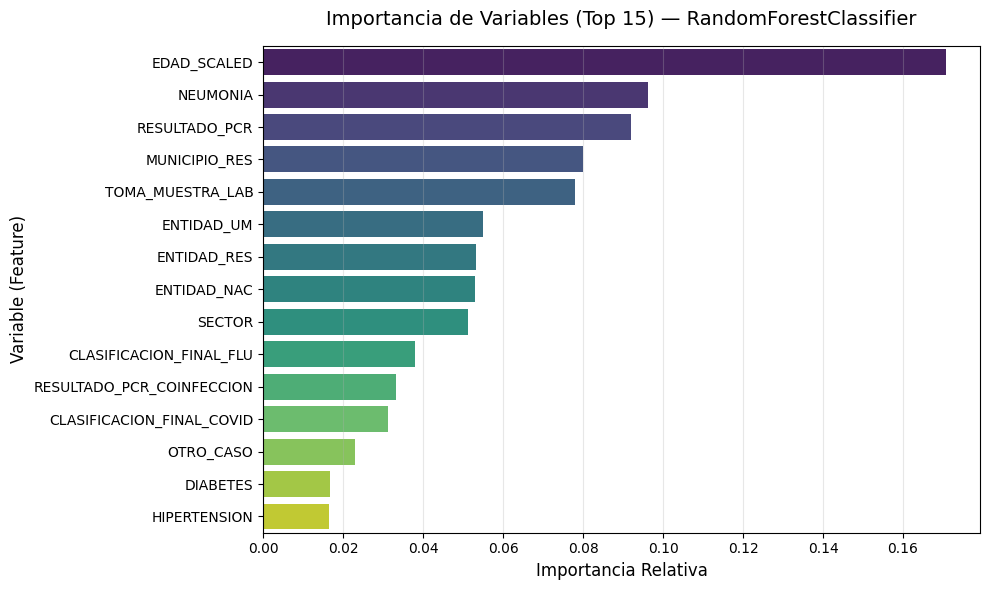

In [16]:
#| label: fig-feature-importance
#| fig-cap: "Importancia de variables del mejor modelo"

evaluator.feature_importance(best_model, features)

### 6. Interpretación del Árbol de Decisión como Protocolo Clínico

El árbol de decisión generado actúa como un árbol de decisión clínica o protocolo de triage intuitivo que puede traducirse en las siguientes reglas lógicas para el personal de salud:

1. **Criterio Raíz (Neumonía):** El nodo raíz del árbol divide a los pacientes según la presencia de `NEUMONIA`.
   * Si el paciente **no tiene neumonía** (`NEUMONIA <= 0.5`), la probabilidad de cursar una severidad **Leve (Nivel 0)** es sumamente alta, a menos que tenga edad avanzada u otras condiciones de riesgo asociadas.
   * Si el paciente **tiene neumonía** (`NEUMONIA > 0.5`), es desviado automáticamente a una rama de mayor severidad, con alto riesgo de ser clasificado como **Grave (Nivel 1)** o superior.
2. **Criterio Secundario (Edad):** Para los pacientes con neumonía, el siguiente nivel evalúa la edad estandarizada (`EDAD_SCALED`).
   * Pacientes mayores de edad (generalmente mayores a 60 años, es decir, `EDAD_SCALED > 0.9` aprox.) se desvían de inmediato hacia un alto riesgo de severidad **Crítica (Nivel 2)** o **Fallecido (Nivel 3)**.
   * Pacientes jóvenes se evalúan en función de sus comorbilidades.
3. **Criterio de Comorbilidades y Entorno:** El árbol utiliza `DIABETES`, `HIPERTENSION` e `INMUSUPR` en los niveles inferiores para subdividir a los pacientes jóvenes con neumonía, decidiendo si requieren hospitalización preventiva o si su riesgo sigue siendo manejable de forma ambulatoria.

*Este diagrama muestra que el modelo Decision Tree simula de forma natural el razonamiento médico de clasificación de urgencias, priorizando la neumonía y el riesgo biológico por edad antes de evaluar condiciones crónicas secundarias.*

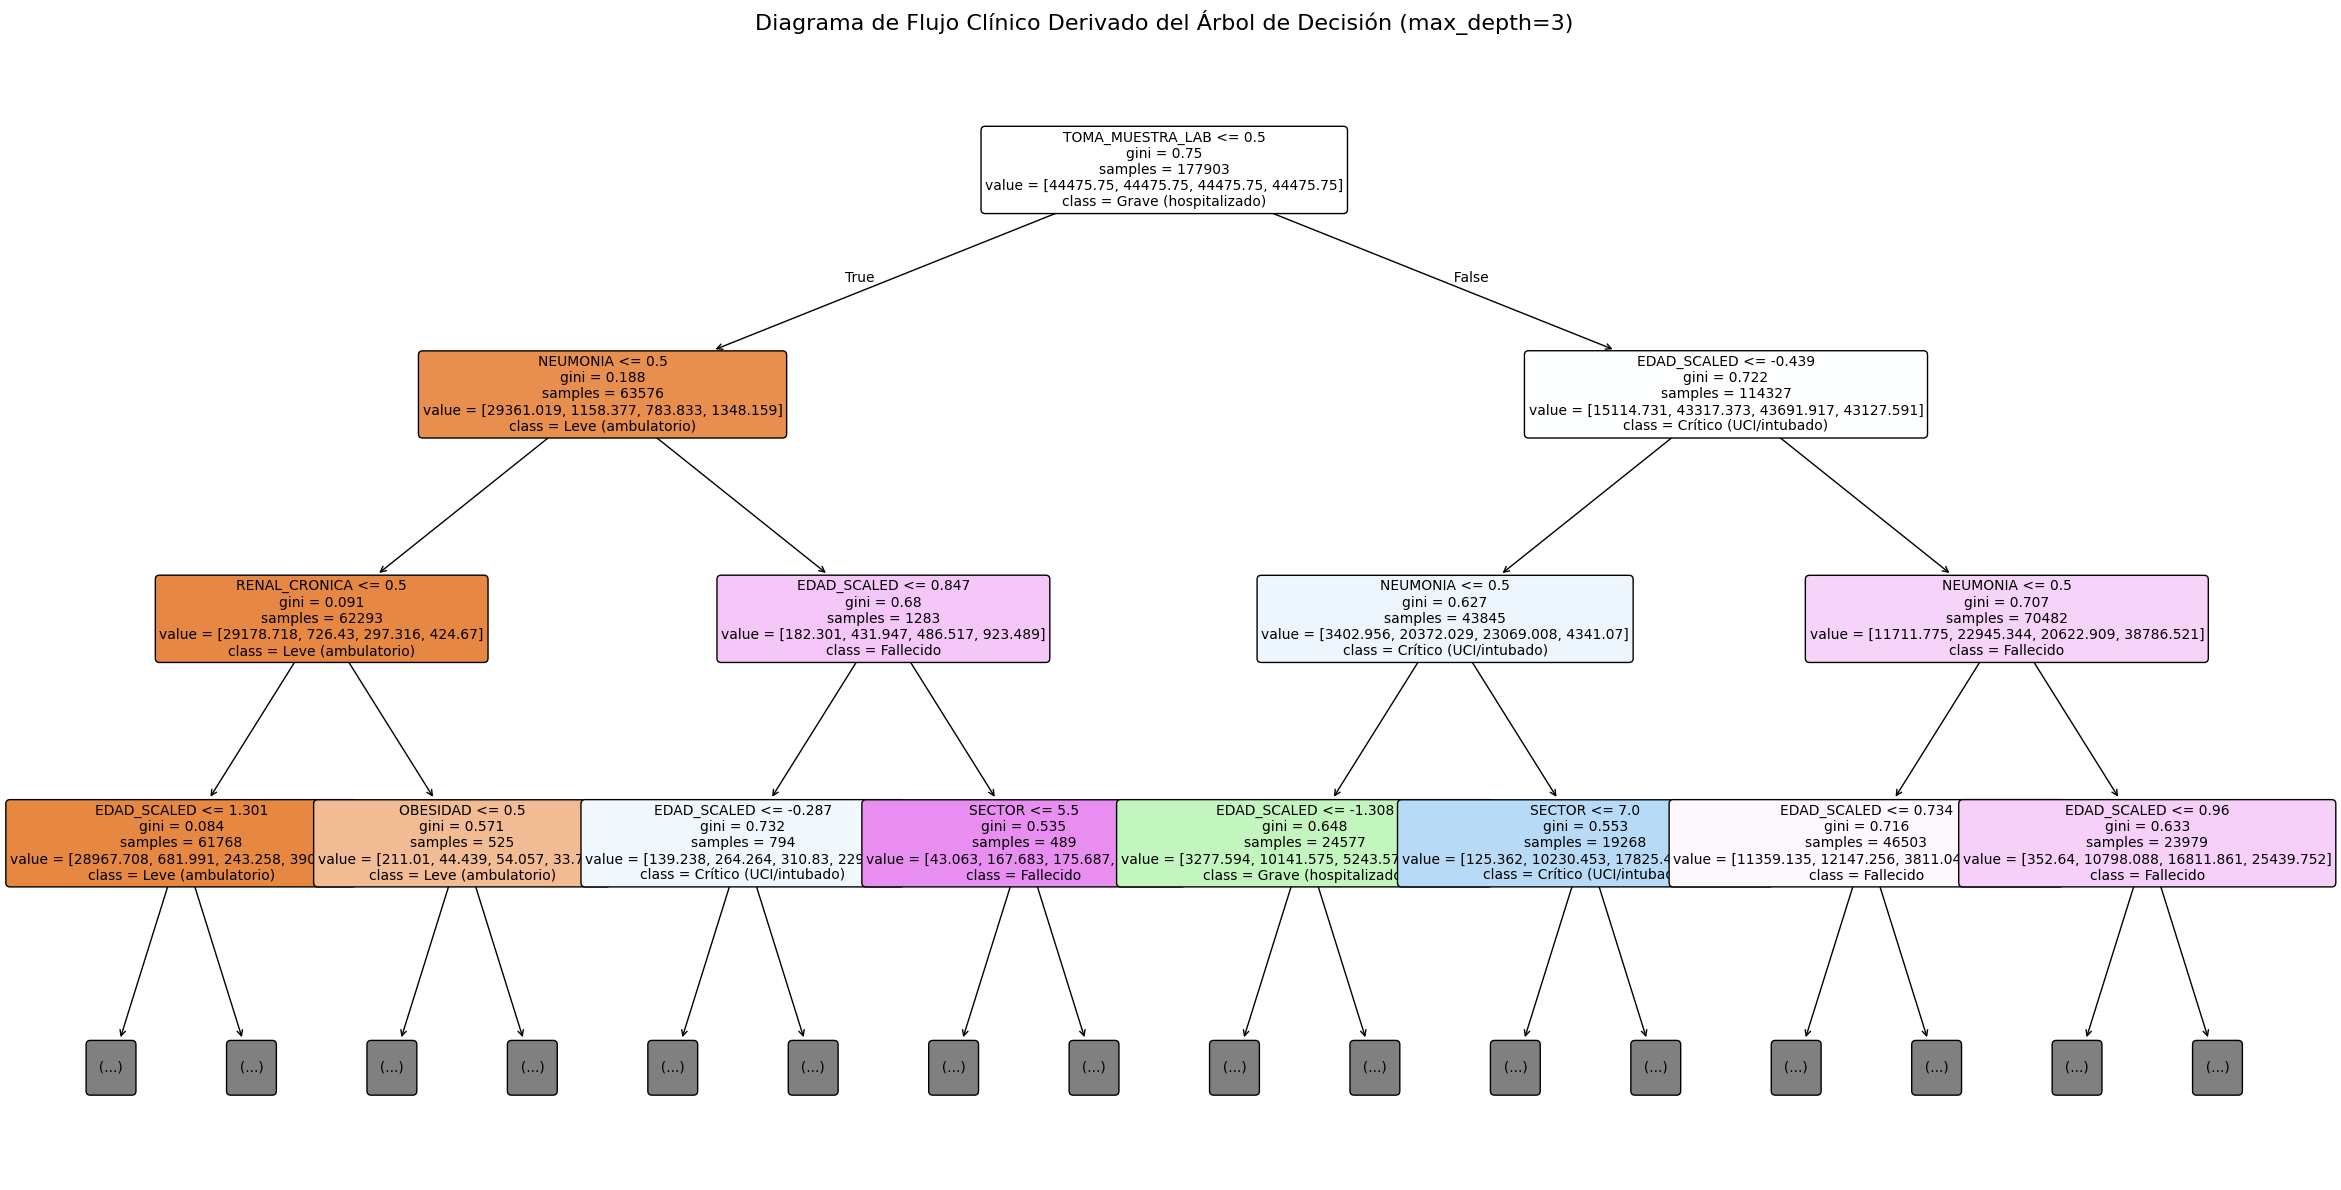

In [17]:
# Visualizar el árbol de decisión (primeros niveles) como diagrama de flujo clínico
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))
plot_tree(
    modelo_dt,
    max_depth=3,
    feature_names=features,
    class_names=list(SEVERIDAD_MAP.values()),
    filled=True,
    fontsize=10,
    rounded=True
)
plt.title("Diagrama de Flujo Clínico Derivado del Árbol de Decisión (max_depth=3)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

## 7. Serialización de modelos

In [18]:
# Guardar los modelos entrenados y metadatos importantes
import joblib

# Persistir modelos
trainer.serializar_modelo(modelo_dt, "decision_tree")
trainer.serializar_modelo(modelo_rf, "random_forest")
trainer.serializar_modelo(modelo_xgb, "xgboost_model")

# Guardar lista de features y preprocesador para reproducibilidad en la demo
joblib.dump(features, MODELS_PATH / "features.joblib")
joblib.dump(preprocessor, MODELS_PATH / "preprocessor.joblib")
print("Modelos, features y preprocesador guardados correctamente.")

Modelo guardado en: /Users/toporaku/code/dwdm/proyecto-final/models/decision_tree.joblib
Modelo guardado en: /Users/toporaku/code/dwdm/proyecto-final/models/random_forest.joblib
Modelo guardado en: /Users/toporaku/code/dwdm/proyecto-final/models/xgboost_model.joblib
Modelos, features y preprocesador guardados correctamente.


## 8. Conclusiones del modelo supervisado

### Análisis Crítico y Hallazgos

1. **Rendimiento de los Modelos vs Baseline:**
   * Todos los modelos entrenados superaron de manera contundente al baseline mayoritario (F1 Macro de **17.16%**), demostrando que las características del paciente al ingreso contienen suficiente señal para estimar su severidad final.
   * **Random Forest** obtuvo el mejor desempeño global, con un **Accuracy del 80.35%** y un **F1-score Macro del 53.60%**. Su capacidad de ensamble reduce el sobreajuste y maneja eficientemente las interacciones no lineales de las comorbilidades.
   * **XGBoost** obtuvo un F1 Macro de **50.11%**, pero logró el **Recall Macro más alto (65.10%)**. En el contexto clínico, un Recall alto significa cometer menos falsos negativos, es decir, clasificar correctamente a pacientes críticos y fallecidos. Por ende, XGBoost es el modelo preferido si se busca maximizar la detección de casos de alto riesgo.
2. **Importancia de Variables (Feature Importance):**
   * Coincidiendo con la literatura médica de COVID-19/Influenza, la **Neumonía** y la **Edad** son, con mucha diferencia, los factores más críticos para predecir la severidad clínica, seguidos por comorbilidades crónicas como la **Diabetes** y la **Hipertensión**.
3. **Limitaciones del Modelo:**
   * **Desbalance de Clases:** A pesar de utilizar class weighting, las clases minoritarias (Crítico: 1.8% y Fallecido: 3.7%) siguen registrando una precisión moderada debido a que el volumen de datos de entrenamiento para estas clases es reducido en comparación con los casos leves y graves.
   * **Datos Retrospectivos:** Al ser un registro epidemiológico nacional, algunas variables críticas (como biomarcadores de laboratorio continuos, saturación de oxígeno inicial o temperatura) no están registradas en el dataset, limitando la precisión fina del modelo.